In [1]:
import hydra
import numpy as np
from data.dmd import DMD



In [2]:
import torch

In [3]:
train = torch.load('../../datasets/train_indices.pt')
test =  torch.load('../../datasets/test_indices.pt')
val = torch.load('../../datasets/val_indices.pt')


In [3]:
set(train).isdisjoint(set(test)), set(train).isdisjoint(set(val)), set(test).isdisjoint(set(val))

(True, True, True)

In [21]:
import pandas as pd

videos = pd.read_csv('../../datasets/dmd_vicomtech.csv', sep=',')
videos

,Ruta_Archivo,Frame_Inicio,Frame_Fin,label
0,dmd/gF/25/s3/gF_25_s3_2019-03-14T14;42;40+01;0...,8,97,safe
1,dmd/gF/25/s3/gF_25_s3_2019-03-14T14;42;40+01;0...,133,724,safe
2,dmd/gF/25/s3/gF_25_s3_2019-03-14T14;42;40+01;0...,985,1324,safe
3,dmd/gF/25/s3/gF_25_s3_2019-03-14T14;42;40+01;0...,1591,1875,safe
4,dmd/gF/25/s3/gF_25_s3_2019-03-14T14;42;40+01;0...,871,984,reaching
...,...,...,...,...
6483,dmd/gZ/32/s2/gZ_32_s2_2019-04-08T16;28;10+02;0...,11465,11512,reaching
6484,dmd/gZ/32/s2/gZ_32_s2_2019-04-08T16;28;10+02;0...,11684,11729,reaching
6485,dmd/gZ/32/s2/gZ_32_s2_2019-04-08T16;28;10+02;0...,12133,12219,reaching
6486,dmd/gZ/32/s2/gZ_32_s2_2019-04-08T16;28;10+02;0...,12474,12590,reaching


(array([3.117e+03, 1.294e+03, 4.770e+02, 3.890e+02, 3.100e+02, 2.490e+02,
        1.720e+02, 1.140e+02, 5.000e+01, 4.200e+01, 1.900e+01, 2.200e+01,
        2.200e+01, 3.000e+01, 2.800e+01, 3.300e+01, 1.200e+01, 2.500e+01,
        1.700e+01, 1.600e+01, 1.200e+01, 7.000e+00, 7.000e+00, 6.000e+00,
        5.000e+00, 5.000e+00, 4.000e+00, 1.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+0

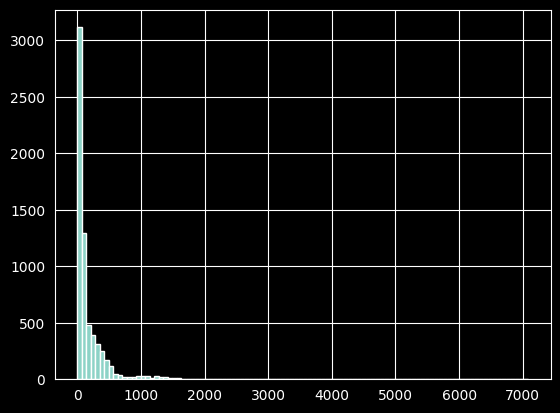

In [27]:
videos['delta']= videos.apply(lambda x: int(x['Frame_Fin'])-int(x['Frame_Inicio']), axis=1)
plt.hist(videos.delta.values, bins=100)


In [6]:
train

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 137,
 138,
 139,
 140,
 141,
 142,
 143,
 144,
 145,
 146,
 147,
 148,
 149,
 150,
 151,
 152,
 153,
 154,
 155,
 156,
 157,
 158,
 159,
 160,
 161,
 162,
 163,
 164,
 165,
 166,
 167,
 168,
 169,
 170,
 171,
 172,
 173,
 174,
 175,
 176,
 177,
 178,
 179,
 180,
 181,
 182,
 183,
 184,


In [7]:
test

[318200,
 318201,
 318202,
 318203,
 318204,
 318205,
 318206,
 318207,
 318208,
 318209,
 318210,
 318211,
 318212,
 318213,
 318214,
 318215,
 318216,
 318217,
 318218,
 318219,
 318220,
 318221,
 318222,
 318223,
 318224,
 318225,
 318226,
 318227,
 318228,
 318229,
 318230,
 318231,
 318232,
 318233,
 318234,
 318235,
 318236,
 318237,
 318238,
 318239,
 318240,
 318241,
 318242,
 318243,
 318244,
 318245,
 318246,
 318247,
 318248,
 318249,
 318250,
 318251,
 318252,
 318253,
 318254,
 318255,
 318256,
 318257,
 318258,
 318259,
 318260,
 318261,
 318262,
 318263,
 318264,
 318265,
 318266,
 318267,
 318268,
 318269,
 318270,
 318271,
 318272,
 318273,
 318274,
 318275,
 318276,
 318277,
 318278,
 318279,
 318280,
 318281,
 318282,
 318283,
 318284,
 318285,
 318286,
 318287,
 318288,
 318289,
 318290,
 318291,
 318292,
 318293,
 318294,
 318295,
 318296,
 318297,
 318298,
 318299,
 318300,
 318301,
 318302,
 318303,
 318304,
 318305,
 318306,
 318307,
 318308,
 318309,
 318310,
 

In [8]:
val

[242887,
 242888,
 242889,
 242890,
 242891,
 242892,
 242893,
 242894,
 242895,
 242896,
 242897,
 242898,
 242899,
 242900,
 242901,
 242902,
 242903,
 242904,
 242905,
 242906,
 242907,
 242908,
 242909,
 242910,
 242911,
 242912,
 242913,
 242914,
 242915,
 242916,
 242917,
 242918,
 242919,
 242920,
 242921,
 242922,
 242923,
 242924,
 242925,
 242926,
 242927,
 242928,
 242929,
 242930,
 242931,
 242932,
 242933,
 242934,
 242935,
 242936,
 242937,
 242938,
 242939,
 242940,
 242941,
 242942,
 242943,
 242944,
 242945,
 242946,
 242947,
 242948,
 242949,
 242950,
 242951,
 242952,
 242953,
 242954,
 242955,
 242956,
 242957,
 242958,
 242959,
 242960,
 242961,
 242962,
 242963,
 242964,
 242965,
 242966,
 242967,
 242968,
 242969,
 242970,
 242971,
 242972,
 242973,
 242974,
 242975,
 242976,
 242977,
 242978,
 242979,
 242980,
 242981,
 242982,
 242983,
 242984,
 242985,
 242986,
 242987,
 242988,
 242989,
 242990,
 242991,
 242992,
 242993,
 242994,
 242995,
 242996,
 242997,
 

In [17]:
videos.shape

(6489, 4)

In [19]:
!pwd

/home/antares/driver_behavior/src/Notebooks


In [4]:
import os
from hydra import initialize, initialize_config_module, initialize_config_dir, compose
from omegaconf import OmegaConf

with initialize(version_base=None,config_path="../configs"):
    cfg = compose("config_local.yaml")
dataset = DMD(cfg)

In [5]:
from torch.utils.data import Subset

train_ds = Subset(dataset, train)
# val_ds = Subset(dataset, val)
# test_ds = Subset(dataset, test)

(array([129330.,      0.,      0.,      0.,      0., 445489.,      0.,
             0.,      0., 482217.]),
 array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ]),
 <BarContainer object of 10 artists>)

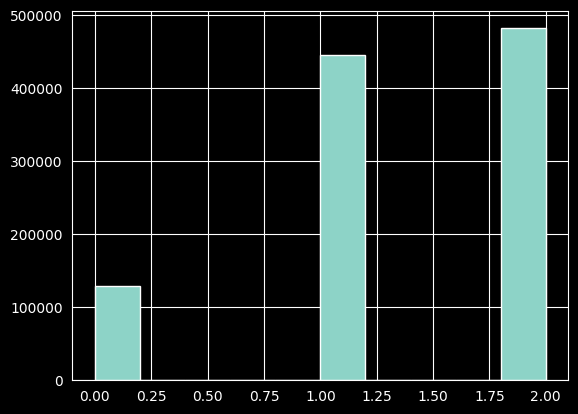

In [10]:
import matplotlib.pyplot as plt
plt.hist(train_ds.dataset.y)

In [15]:
dataset.le.classes_

array(['reaching', 'safe', 'unsafe'], dtype='<U8')

In [1]:
import re
from collections import defaultdict
import random
import csv

# Recolectar: sujeto → lista de slices
subject_slices = defaultdict(list)

with open('../../datasets/dmd_vicomtech.csv') as f:
    reader = csv.reader(f)
    next(reader)
    for i, row in enumerate(reader):
        path = row[0]
        # extraer sujeto: dmd/gF/25/s3/... → '25' (o 'gF_25' si grupos importan)
        match = re.match(r'dmd/(\w+)/(\d+)/', path)
        if match:
            subject_id = f"{match.group(1)}_{match.group(2)}"
            subject_slices[subject_id].append(i)

subjects = sorted(subject_slices.keys())
print(f"Sujetos únicos: {len(subjects)}")

# Split aproximado 70/15/15 por sujeto
random.seed(42)
random.shuffle(subjects)
n = len(subjects)
n_train = int(0.7 * n)
n_val = int(0.15 * n)

train_subjects = set(subjects[:n_train])
val_subjects = set(subjects[n_train:n_train + n_val])
test_subjects = set(subjects[n_train + n_val:])

train_idx = [i for s in train_subjects for i in subject_slices[s]]
val_idx = [i for s in val_subjects for i in subject_slices[s]]
test_idx = [i for s in test_subjects for i in subject_slices[s]]

print(f"Train: {len(train_idx)} slices, {len(train_subjects)} sujetos")
print(f"Val: {len(val_idx)} slices, {len(val_subjects)} sujetos")
print(f"Test: {len(test_idx)} slices, {len(test_subjects)} sujetos")

Sujetos únicos: 29
Train: 4318 slices, 20 sujetos
Val: 960 slices, 4 sujetos
Test: 1210 slices, 5 sujetos
